<a href="https://colab.research.google.com/github/AnnabelleMcSharry/AI-ML-Car-Data/blob/main/salesForcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

sales = pd.read_csv("sales forecasting.csv")

In [46]:
print("Missing values:\n", sales.isnull().sum())

# Check for duplicates
print("Duplicates:\n", sales.duplicated().sum())

# Count total number of rows
print("Total number of rows:", sales.shape[0])

Missing values:
 Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64
Duplicates:
 0
Total number of rows: 5681


In [47]:
#analysis to see how much data would be lost if i just dropped all of the line swith missing values

new_sales = sales.dropna()

print("Total records that would be lost if deleted:")
print(sales.shape[0] - new_sales.shape[0])

#45% too high to just drop all values so will ahve to do further analysis
print("Percentage of records lost:")
print(((sales.shape[0] - new_sales.shape[0]) / sales.shape[0]) * 100)


Total records that would be lost if deleted:
2582
Percentage of records lost:
45.44974476324591


In [48]:
#counts how many times each outlet size appears including howmany times a missing value appears

print(sales["Outlet_Size"].value_counts(dropna=False))

#shows the percentage of each time the different outlet size occurs
#28% is too much to delete
print(sales["Outlet_Size"].value_counts(normalize=True, dropna=False) * 100)


Outlet_Size
Medium    1862
NaN       1606
Small     1592
High       621
Name: count, dtype: int64
Outlet_Size
Medium    32.775920
NaN       28.269671
Small     28.023235
High      10.931174
Name: proportion, dtype: float64


In [49]:
#checking to see if outlet size is linked to outlet type to see if i can fill in the values mnaually
print(pd.crosstab(sales["Outlet_Type"], sales["Outlet_Size"], dropna=False))

#shows how many outlet types have missing values- all missiing values are in grocery store or supermarket type 1
#50% of super market type 1 is small
#grocery stores are all small if they ahve a value
print(pd.crosstab(sales["Outlet_Type"], sales["Outlet_Size"].isnull()))



Outlet_Size        High  Medium  Small   NaN
Outlet_Type                                 
Grocery Store         0       0    352   370
Supermarket Type1   621     620   1240  1236
Supermarket Type2     0     618      0     0
Supermarket Type3     0     624      0     0
Outlet_Size        False  True 
Outlet_Type                    
Grocery Store        352    370
Supermarket Type1   2481   1236
Supermarket Type2    618      0
Supermarket Type3    624      0


In [50]:
#all known grocery stores are small so i will change them all to small
sales.loc[
    (sales["Outlet_Type"] == "Grocery Store") & (sales["Outlet_Size"].isnull()),"Outlet_Size"] = "Small"

In [51]:
#because there is almost exact 25-25-50 split for supermarlet type 1 between high-medium-small i used this distribution to fill the missing values
import numpy as np

# Select missing Outlet_Size rows where Outlet_Type is Supermarket Type1
missing_type1 = ((sales["Outlet_Type"] == "Supermarket Type1") &(sales["Outlet_Size"].isnull()))

# Calculate the existing size distribution for known Supermarket Type1 rows
type1_distribution = sales.loc[(sales["Outlet_Type"] == "Supermarket Type1") &(sales["Outlet_Size"].notnull()),"Outlet_Size"].value_counts(normalize=True)

print(type1_distribution)

# Fill missing values using the same distribution
np.random.seed(42)

sales.loc[missing_type1, "Outlet_Size"] = np.random.choice(type1_distribution.index,size=missing_type1.sum(),p=type1_distribution.values)


Outlet_Size
Small     0.499798
High      0.250302
Medium    0.249899
Name: proportion, dtype: float64


In [52]:
print("Missing values:\n", sales.isnull().sum())

# Check for duplicates
print("Duplicates:\n", sales.duplicated().sum())

# Count total number of rows
print("Total number of rows:", sales.shape[0])


Missing values:
 Item_Identifier                0
Item_Weight                  976
Item_Fat_Content               0
Item_Visibility                0
Item_Type                      0
Item_MRP                       0
Outlet_Identifier              0
Outlet_Establishment_Year      0
Outlet_Size                    0
Outlet_Location_Type           0
Outlet_Type                    0
dtype: int64
Duplicates:
 0
Total number of rows: 5681


count    4705.000000
mean       12.695633
std         4.664849
min         4.555000
25%         8.645000
50%        12.500000
75%        16.700000
max        21.350000
Name: Item_Weight, dtype: float64
Percentage of missing weights:
17.180073930646014


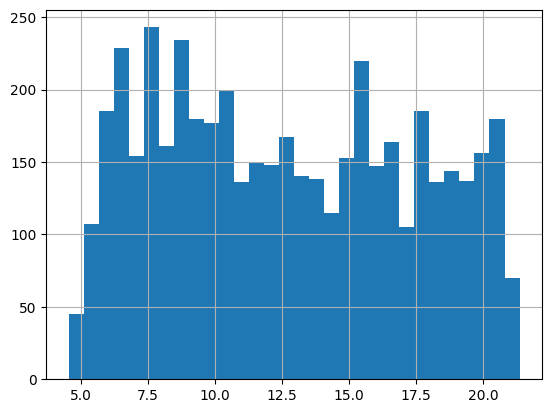

In [53]:
#looking at the distributions of the weight so i can try to figure out how to best deal with the missing data

print(sales["Item_Weight"].describe())

sales["Item_Weight"].hist(bins=30)

print("Percentage of missing weights:")
print((sales["Item_Weight"].isnull().sum() / len(sales)) * 100)

#17% is missing a weight which is too high to delete

In [54]:
# Check whether missing Item_Weight values can be filled using the same item sold in other stores

total_missing_weight_rows = sales["Item_Weight"].isnull().sum()

unique_items_with_missing_weight = sales.loc[
    sales["Item_Weight"].isnull(),
    "Item_Identifier"
].nunique()

# Count how many known weight values each item has
known_weights_per_item = sales.groupby("Item_Identifier")["Item_Weight"].nunique()

items_with_known_weight = (known_weights_per_item > 0).sum()
items_with_no_known_weight = (known_weights_per_item == 0).sum()

print("Number of rows that do not have a weight", total_missing_weight_rows)
print("The number of unique items without a weight", unique_items_with_missing_weight)
print("Number of items with known weights in other stores", items_with_known_weight)
print("Number of items with no weight in the whole database", items_with_no_known_weight)



Number of rows that do not have a weight 976
The number of unique items without a weight 845
Number of items with known weights in other stores 1527
Number of items with no weight in the whole database 16


In [55]:
# Fill missing Item_Weight values using the same item's known weight
sales["Item_Weight"] = sales.groupby("Item_Identifier")["Item_Weight"].transform(
    lambda x: x.fillna(x.mean())
)

# Check how many missing values are left
print("Missing Item_Weight values remaining:")
print(sales["Item_Weight"].isnull().sum())


Missing Item_Weight values remaining:
20


In [56]:
#droppning the remaining items without a weight as i will only lose 20 records
sales = sales.dropna(subset=["Item_Weight"])





In [57]:
#getting rid of the identifiers beacsue they are not factors that will help with regression they are descriptive

sales = sales.drop(columns=["Item_Identifier", "Outlet_Identifier"])
print(sales.head())
print(sales.columns)


   Item_Weight Item_Fat_Content  Item_Visibility    Item_Type  Item_MRP  \
0       20.750          Low Fat         0.007565  Snack Foods  107.8622   
1        8.300              reg         0.038428        Dairy   87.3198   
2       14.600          Low Fat         0.099575       Others  241.7538   
3        7.315          Low Fat         0.015388  Snack Foods  155.0340   
4       13.600          Regular         0.118599        Dairy  234.2300   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2007       Small               Tier 2   
2                       1998       Small               Tier 3   
3                       2007      Medium               Tier 2   
4                       1985      Medium               Tier 3   

         Outlet_Type  
0  Supermarket Type1  
1  Supermarket Type1  
2      Grocery Store  
3  Supermarket Type1  
4  Supermarket Type3  
Index(['Item_Weight'

In [58]:
#finding unique values before i encode
categorical_columns = ["Item_Fat_Content", "Item_Type", "Outlet_Size", "Outlet_Location_Type","Outlet_Type"]

for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(sales[col].unique())



Unique values in Item_Fat_Content:
['Low Fat' 'reg' 'Regular' 'LF' 'low fat']

Unique values in Item_Type:
['Snack Foods' 'Dairy' 'Others' 'Fruits and Vegetables' 'Baking Goods'
 'Health and Hygiene' 'Breads' 'Hard Drinks' 'Seafood' 'Soft Drinks'
 'Household' 'Frozen Foods' 'Meat' 'Canned' 'Starchy Foods' 'Breakfast']

Unique values in Outlet_Size:
['Medium' 'Small' 'High']

Unique values in Outlet_Location_Type:
['Tier 1' 'Tier 2' 'Tier 3']

Unique values in Outlet_Type:
['Supermarket Type1' 'Grocery Store' 'Supermarket Type3'
 'Supermarket Type2']


In [59]:
#merging the fat content column as the labels all just mean regular or low fat
sales["Item_Fat_Content"] = sales["Item_Fat_Content"].replace({"LF": "Low Fat","low fat": "Low Fat","reg": "Regular" })

print(sales["Item_Fat_Content"].unique())
print(sales["Item_Fat_Content"].value_counts())


['Low Fat' 'Regular']
Item_Fat_Content
Low Fat    3654
Regular    2007
Name: count, dtype: int64


In [60]:
#encoding fat content
sales = pd.get_dummies( sales, columns=["Item_Fat_Content"], drop_first=True,  dtype=int)
print(sales.head())
print(sales.columns)

   Item_Weight  Item_Visibility    Item_Type  Item_MRP  \
0       20.750         0.007565  Snack Foods  107.8622   
1        8.300         0.038428        Dairy   87.3198   
2       14.600         0.099575       Others  241.7538   
3        7.315         0.015388  Snack Foods  155.0340   
4       13.600         0.118599        Dairy  234.2300   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2007       Small               Tier 2   
2                       1998       Small               Tier 3   
3                       2007      Medium               Tier 2   
4                       1985      Medium               Tier 3   

         Outlet_Type  Item_Fat_Content_Regular  
0  Supermarket Type1                         0  
1  Supermarket Type1                         1  
2      Grocery Store                         0  
3  Supermarket Type1                         0  
4  Supermarket 

remeber what the type of encoding you use for when there is high cardinality and use it on item type
ordinal encoding on outlet size and location type
one hot encoding for outlet type